In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer

import random
import numpy as np
import tensorflow as tf
import os




2026-06-29 10:38:18.196647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782729498.220281     160 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782729498.228216     160 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782729498.247095     160 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782729498.247115     160 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782729498.247117     160 computation_placer.cc:177] computation placer alr

In [5]:
df = pd.read_csv('/kaggle/input/datasets/razanalkhamisi/amazon-reviews/data.csv')
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [6]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28646 entries, 0 to 28645
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28646 non-null  object 
 1   dateAdded            28646 non-null  object 
 2   dateUpdated          28646 non-null  object 
 3   name                 28646 non-null  object 
 4   asins                28646 non-null  object 
 5   brand                28646 non-null  object 
 6   categories           28646 non-null  object 
 7   primaryCategories    28646 non-null  object 
 8   imageURLs            28646 non-null  object 
 9   keys                 28646 non-null  object 
 10  manufacturer         28646 non-null  object 
 11  manufacturerNumber   28646 non-null  object 
 12  reviews.date         28646 non-null  object 
 13  reviews.dateSeen     28379 non-null  object 
 14  reviews.didPurchase  323 non-null    object 
 15  reviews.doRecommend  16400 non-null 

In [8]:
print(df['categories'].value_counts())

categories
AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care                                                                                                                                                                                                                                                                                                                                                    8343
AA,AAA,Electronics Features,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care                                                                                                                     

In [9]:
print(df['reviews.rating'].value_counts())

reviews.rating
5    19897
4     5648
3     1403
1     1028
2      670
Name: count, dtype: int64


In [10]:

def map_sentiment(rating):
    if rating >= 4:
        return 1  # Positive
    else:
        return 0  # Negative

df['sentiment'] = df['reviews.rating'].apply(map_sentiment)


df['sentiment']=df['reviews.rating'].apply(map_sentiment)
df.head()


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,sentiment
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht...",0
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht...",1
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht...",1
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht...",1
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht...",1


In [11]:
print(df['sentiment'].value_counts())

sentiment
1    25545
0     3101
Name: count, dtype: int64


In [12]:

# For each sentiment class, randomly sample 1400 rows to balance the dataset
# group_keys=False ensures the original index structure is not kept

df = df.groupby('sentiment', group_keys=False).apply(lambda x: x.sample(n=3101, random_state=42)).reset_index(drop=True)

print(df['sentiment'].value_counts())


sentiment
0    3101
1    3101
Name: count, dtype: int64


/tmp/ipykernel_160/3466631966.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('sentiment', group_keys=False).apply(lambda x: x.sample(n=3101, random_state=42)).reset_index(drop=True)


In [13]:
print(df["sentiment"].value_counts())

sentiment
0    3101
1    3101
Name: count, dtype: int64


In [14]:

important_features = df[['reviews.text', 'reviews.title']]

label=df['sentiment']

train_features, test_features, train_labels, test_labels = train_test_split(
    important_features,
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [15]:
import re

# Function to clean text data
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

train_features['reviews.text'] = train_features['reviews.text'].apply(clean_text)
test_features['reviews.text'] = test_features['reviews.text'].apply(clean_text)

train_features['reviews.title'] = train_features['reviews.title'].fillna("")
test_features['reviews.title'] = test_features['reviews.title'].fillna("")



#Classification

In [16]:
from transformers import BertTokenizer

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Combine text and title columns into one string for train and test sets
train_texts = train_features['reviews.text'].astype(str).str.cat(train_features['reviews.title'].astype(str), sep=" ")
test_texts = test_features['reviews.text'].astype(str).str.cat(test_features['reviews.title'].astype(str), sep=" ")

# Tokenize the concatenated text with truncation and padding
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256, return_tensors="tf")
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256, return_tensors="tf")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

I0000 00:00:1782729558.453751     160 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [17]:
# Function to convert encodings and labels into TensorFlow dataset
def convert_to_tf_dataset(encodings, labels):
    dataset = tf.data.Dataset.from_tensor_slices((
        dict(encodings),  # Convert encodings to dictionary
        tf.convert_to_tensor(labels)  # Convert labels to tensor
    ))
    return dataset

batch_size = 32

# Convert the data into TensorFlow datasets
train_dataset = convert_to_tf_dataset(train_encodings, train_labels).shuffle(1000).batch(batch_size)
test_dataset = convert_to_tf_dataset(test_encodings, test_labels).batch(batch_size)


In [18]:
df['sentiment'].value_counts()

sentiment
0    3101
1    3101
Name: count, dtype: int64

In [ ]:
import tensorflow as tf
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint
from transformers import (
    TFBertForSequenceClassification,
    BertConfig,
    create_optimizer
)

# ===============================
# Model Configuration
# ===============================

config = BertConfig.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
)

model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    config=config
)

# ===============================
# Training Parameters
# ===============================

batch_size = 16      # 16 is often better than 32 for BERT
epochs = 12

num_train_steps = len(train_dataset) * epochs
warmup_steps = int(0.1 * num_train_steps)

# ===============================
# Optimizer
# ===============================

optimizer, lr_schedule = create_optimizer(
    init_lr=2e-5,
    num_warmup_steps=warmup_steps,
    num_train_steps=num_train_steps,
    weight_decay_rate=0.01
)


optimizer.global_clipnorm = 1.0

# ===============================
# Loss
# ===============================

loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

# ===============================
# Callbacks
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_bert.weights.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# ===============================
# Train
# ===============================

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    callbacks=[early_stop, checkpoint]
)

# ===============================
# Load Best Model
# ===============================

model.load_weights("best_bert.weights.h5")

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/12
156/156 [==============================] - ETA: 0s - loss: 0.5418 - accuracy: 0.7224
Epoch 1: val_accuracy improved from -inf to 0.89766, saving model to best_bert.weights.h5


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


156/156 [==============================] - 184s 1s/step - loss: 0.5418 - accuracy: 0.7224 - val_loss: 0.2823 - val_accuracy: 0.8977
Epoch 2/12
156/156 [==============================] - ETA: 0s - loss: 0.2412 - accuracy: 0.9119
Epoch 2: val_accuracy improved from 0.89766 to 0.91620, saving model to best_bert.weights.h5
156/156 [==============================] - 166s 1s/step - loss: 0.2412 - accuracy: 0.9119 - val_loss: 0.2229 - val_accuracy: 0.9162
Epoch 3/12
156/156 [==============================] - ETA: 0s - loss: 0.1550 - accuracy: 0.9502
Epoch 3: val_accuracy improved from 0.91620 to 0.93070, saving model to best_bert.weights.h5
156/156 [==============================] - 165s 1s/step - loss: 0.1550 - accuracy: 0.9502 - val_loss: 0.2417 - val_accuracy: 0.9307
Epoch 4/12
156/156 [==============================] - ETA: 0s - loss: 0.1071 - accuracy: 0.9686
Epoch 4: val_accuracy improved from 0.93070 to 0.93956, saving model to best_bert.weights.h5
156/156 [============================

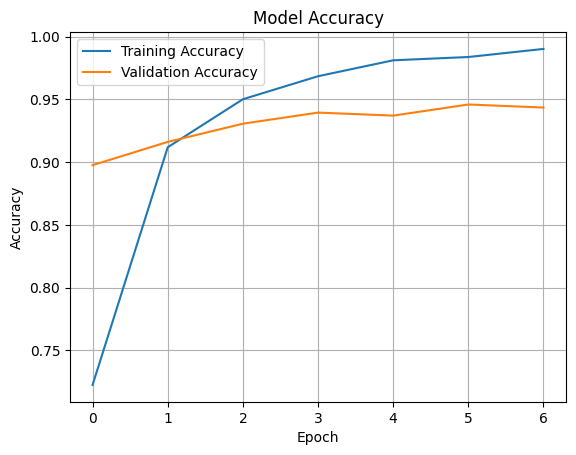

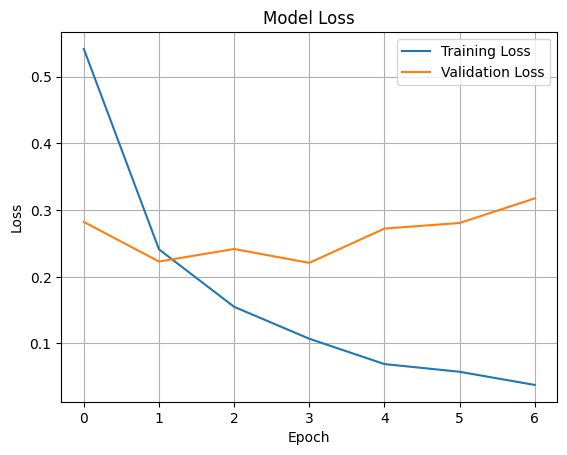

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


39/39 [==============================] - 15s 324ms/step


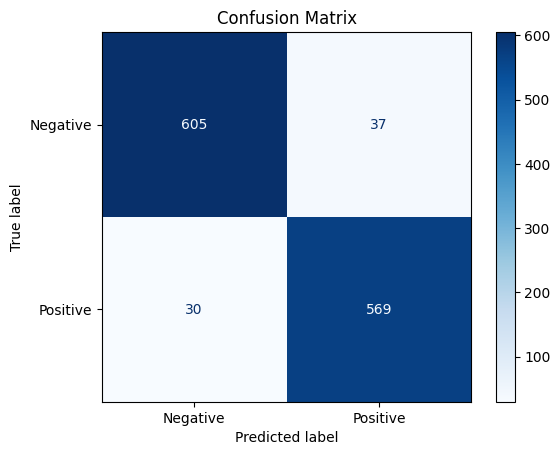

In [25]:
import numpy as np

predictions = model.predict(test_dataset).logits

predicted_labels = np.argmax(predictions, axis=1)

true_labels = []
for _, label in test_dataset:
    true_labels.extend(label.numpy())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [28]:
model.load_weights("best_bert.weights.h5")

model.save_pretrained("/kaggle/working/saved_model_directory")
tokenizer.save_pretrained("/kaggle/working/saved_model_directory")


('/kaggle/working/saved_model_directory/tokenizer_config.json',
 '/kaggle/working/saved_model_directory/special_tokens_map.json',
 '/kaggle/working/saved_model_directory/vocab.txt',
 '/kaggle/working/saved_model_directory/added_tokens.json')